In [13]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec

In [14]:
### Load Data frame ###

directory = 'C:/Users/cfo/Desktop/Transient Record Marine'
specific_file = 'TR_Data'
data_path = os.path.join(directory, specific_file)
start = 3083 # First TR file
stop = 4106 # Last TR file

image_size = [2000, 2000]
grid_size = [32, 32]

# Load data frame
file_name = os.path.join(data_path, f'Data_frame_from_{start}_to_{stop}.pkl')
df = pd.read_pickle(file_name) # 1026 colums, column 0: index, column 1: time in s

In [15]:
### Calculate the mean current for each TR_current ###

list_col = list(range(start, stop+1))

list_mean = []

for j in list_col:

    col = df[f'TR_{str(j).zfill(4)}']
    list_mean.append(col.mean())


C:\Users\cfo\AppData\Local\Temp\ipykernel_14032\1053581714.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap1 = cm.get_cmap(name='viridis', lut=None)


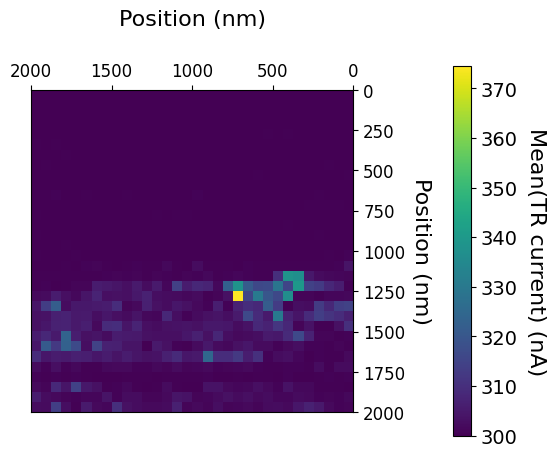

In [24]:
data_mean = np.array(list_mean).reshape(grid_size[0], grid_size[1]) * 1e9 #nA

fig = plt.figure()
spec = gridspec.GridSpec(ncols=1, nrows=1)
cmap1 = cm.get_cmap(name='viridis', lut=None)

ax1 = fig.add_subplot(spec[0])

plt.imshow(data_mean, cmap=cmap1, extent=[image_size[1], 0, image_size[0], 0], interpolation='none')
clb = plt.colorbar(pad=0.2)
clb.set_label('Mean(TR current) (nA)', labelpad=20, y=0.5, rotation=270, fontsize=16)

clb.ax.tick_params(labelsize=14)
ax1.set_ylabel('Position (nm)', rotation=270, fontsize=16)
ax1.set_xlabel('Position (nm)', fontsize=16)
ax1.tick_params(axis='x', labelsize=12)
ax1.tick_params(axis='y', labelsize=12)
ax1.xaxis.tick_top()
ax1.yaxis.tick_right()
ax1.xaxis.set_label_coords(0.5, 1.25)
ax1.yaxis.set_label_coords(1.18, 0.5)

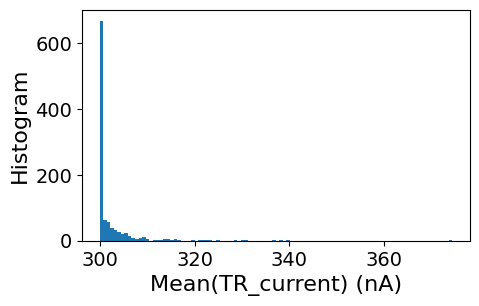

In [20]:
### Histogram ###

data_mean_h = np.copy(data_mean)
data_mean_h = data_mean.flatten()

fig = plt.figure()
fig.set_figheight(3)
fig.set_figwidth(5)
spec = gridspec.GridSpec(ncols=1, nrows=1)

ax1 = fig.add_subplot(spec[0])
plt.hist(data_mean_h, bins=100)
ax1.set_ylabel('Histogram', fontsize=16)
ax1.set_xlabel('Mean(TR_current) (nA)', fontsize=16)
ax1.tick_params(axis='x', labelsize=14)
ax1.tick_params(axis='y', labelsize=14)

plt.show()

